# 23. Classical Iterative Methods

**Part 4: Iterative and Krylov Subspace Methods**

## Learning objectives

By the end of this lesson you will be able to:

1. Say when an **iterative** method is the right choice and when a direct one is.
2. Write any stationary iteration as a **matrix splitting** $A = M - N$.
3. Derive **Jacobi**, **Gauss-Seidel** and **SOR** as three choices of $M$.
4. State and use the convergence theorem: $\rho(G) < 1$, and the rate is $\rho(G)$.
5. Explain why Gauss-Seidel is about twice as fast as Jacobi, and prove it for the model
   problem.
6. Explain why **SOR changes the order** of the convergence rate, not merely the constant.
7. Use Kahan's theorem to bound $\omega$, and measure how sharp the optimum is.
8. Recognise that all three stall on the same thing, which is what Parts 4 and lesson 28 fix.

## Prerequisites

Lesson 15 (norms, spectral radius, Gelfand's formula). Lesson 21 (sparsity, the second
difference matrix). Lesson 10 for scalar fixed point theory and lesson 14 for its $n$
dimensional version, which this lesson is a special case of.

---

## 1. When to stop factorizing

Lesson 21 measured the wall: at $n = 10^6$ a dense matrix needs 8 terabytes. Sparsity fixes the
storage of $A$, and lesson 21 showed that fill can destroy the storage of $L$ and $U$ anyway.

An iterative method never forms a factorization at all. It needs only the ability to compute
$A\mathbf{x}$, so it needs exactly the memory $A$ already occupies.

| | Direct | Iterative |
|---|---|---|
| Cost | fixed, $O(n^3)$ dense or fill-dependent sparse | per iteration $O(\text{nnz})$, count unknown in advance |
| Memory | the factors, which may be far denser than $A$ | $A$ plus a few vectors |
| Accuracy | machine precision, once | whatever you iterate to |
| Stops when | it is finished | **you decide** |
| Reuse for a new $\mathbf{b}$ | nearly free | start again |
| Needs | the entries of $A$ | only $A\mathbf{x}$ |

The last row is the one that matters most, and lesson 26 builds on it: a method that only ever
needs $A\mathbf{x}$ can solve problems where $A$ is never assembled at all.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import iterative as it, banded as bd, linalg as la, cholesky as ch

print("cost per sweep against a direct solve, on the model problem\n")
print(f"{'n':>8} {'nnz':>10} {'one sweep':>13} {'dense LU':>16} {'sweeps affordable':>20}")
print("-" * 72)
for n in [100, 1000, 10000, 100000]:
    nnz = 3 * n - 2                      # tridiagonal
    sweep = 2 * nnz                      # one matvec
    direct = 2 * n**3 / 3
    print(f"{n:>8,} {nnz:>10,} {sweep:>13,} {direct:>16.3e} {direct/sweep:>20,.0f}")

print()
print("at n = 100000 you could afford eight hundred million sweeps for the price")
print("of one dense factorization. the question is never 'is a sweep cheap', it")
print("is 'how many sweeps do I need', and that is what the rest of this lesson")
print("is about.")

cost per sweep against a direct solve, on the model problem

       n        nnz     one sweep         dense LU    sweeps affordable
------------------------------------------------------------------------
     100        298           596        6.667e+05                1,119
   1,000      2,998         5,996        6.667e+08              111,185
  10,000     29,998        59,996        6.667e+11           11,111,852
 100,000    299,998       599,996        6.667e+14        1,111,118,519

at n = 100000 you could afford eight hundred million sweeps for the price
of one dense factorization. the question is never 'is a sweep cheap', it
is 'how many sweeps do I need', and that is what the rest of this lesson
is about.


## 2. Every stationary method is a splitting

Write $A = M - N$ with $M$ easy to invert. Then

$$A\mathbf{x} = \mathbf{b}
\iff M\mathbf{x} = N\mathbf{x} + \mathbf{b}
\iff \mathbf{x} = M^{-1}N\mathbf{x} + M^{-1}\mathbf{b},$$

which is a fixed point equation. Iterate it:

$$\boxed{\mathbf{x}_{k+1} = G\mathbf{x}_k + \mathbf{c}, \qquad
G = M^{-1}N, \quad \mathbf{c} = M^{-1}\mathbf{b}.}$$

$G$ is the **iteration matrix**, and everything about convergence is a statement about it.

Splitting $A = D + L + U$ into diagonal, strict lower and strict upper parts gives the three
classical choices:

| Method | $M$ | Idea |
|---|---|---|
| **Jacobi** | $D$ | invert only the diagonal |
| **Gauss-Seidel** | $D + L$ | invert the whole lower triangle, which is a forward solve |
| **SOR** | $D/\omega + L$ | a weighted blend, tuned by $\omega$ |

Each $M$ is cheap to invert: $D$ trivially, $D + L$ by forward substitution at $O(\text{nnz})$.

In [3]:
A = bd.second_difference(6)
D, L, U = it.split(A)
print("A =\n", A.astype(int))
print("\nD =\n", D.astype(int))
print("\nL =\n", L.astype(int))
print("\nU =\n", U.astype(int))
print(f"\nA = D + L + U exactly: {np.abs(D + L + U - A).max():.1e}")
np.testing.assert_allclose(D + L + U, A)

A =
 [[ 2 -1  0  0  0  0]
 [-1  2 -1  0  0  0]
 [ 0 -1  2 -1  0  0]
 [ 0  0 -1  2 -1  0]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0  0 -1  2]]

D =
 [[2 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 2 0 0 0]
 [0 0 0 2 0 0]
 [0 0 0 0 2 0]
 [0 0 0 0 0 2]]

L =
 [[ 0  0  0  0  0  0]
 [-1  0  0  0  0  0]
 [ 0 -1  0  0  0  0]
 [ 0  0 -1  0  0  0]
 [ 0  0  0 -1  0  0]
 [ 0  0  0  0 -1  0]]

U =
 [[ 0 -1  0  0  0  0]
 [ 0  0 -1  0  0  0]
 [ 0  0  0 -1  0  0]
 [ 0  0  0  0 -1  0]
 [ 0  0  0  0  0 -1]
 [ 0  0  0  0  0  0]]

A = D + L + U exactly: 0.0e+00


## 3. The convergence theorem

> **Theorem 23.1.** The iteration $\mathbf{x}_{k+1} = G\mathbf{x}_k + \mathbf{c}$ converges to
> the unique fixed point from **every** starting vector if and only if
> $$\rho(G) < 1,$$
> and the asymptotic rate is $\rho(G)$.
>
> *Proof.* Let $\mathbf{x}^\ast$ be the fixed point and $\mathbf{e}_k = \mathbf{x}_k -
> \mathbf{x}^\ast$. Subtracting $\mathbf{x}^\ast = G\mathbf{x}^\ast + \mathbf{c}$ from the
> iteration gives $\mathbf{e}_{k+1} = G\mathbf{e}_k$, hence
> $$\mathbf{e}_k = G^k\mathbf{e}_0.$$
> So convergence from every $\mathbf{e}_0$ is exactly the statement $G^k \to 0$, which by
> Gelfand's formula (lesson 15, Theorem 15.5) holds if and only if $\rho(G) < 1$. The same
> formula gives $\|G^k\|^{1/k} \to \rho(G)$, which is the rate. $\square$

**This is lesson 10's theorem with $|g'(r)|$ replaced by $\rho(G)$**, and lesson 14's Theorem
14.1 specialised to a linear map. The same inequality has now appeared three times.

Two consequences worth stating separately:

- **A norm is not the criterion.** $\|G\| < 1$ is sufficient and not necessary. Lesson 15
  section 6 measured a matrix with $\rho = 0.9$ and $\|G\|_2 = 4.17$, whose powers grew for six
  steps before decaying.
- **The rate is asymptotic.** Early behaviour is governed by the norm, and that transient is
  real.

In [4]:
print("the criterion, and the rate it predicts\n")
n = 20
A = bd.second_difference(n)
print(f"{'method':>14} {'rho(G)':>12} {'converges?':>12} {'predicted iters to 1e-10':>26}")
print("-" * 68)
for method, omega in [("jacobi", 1.0), ("gauss-seidel", 1.0),
                      ("sor", it.optimal_omega(A))]:
    G = it.iteration_matrix(A, method, omega)
    rho = it.spectral_radius(G)
    label = method if method != "sor" else f"sor (w={omega:.3f})"
    print(f"{label:>14} {rho:>12.6f} {str(rho < 1):>12} "
          f"{it.iterations_needed(rho):>26.0f}")

print()
print("all three converge. the predicted counts differ by a factor of 27, and")
print("nothing about that is visible from the matrix itself: it comes entirely")
print("from rho(G).")

the criterion, and the rate it predicts

        method       rho(G)   converges?   predicted iters to 1e-10
--------------------------------------------------------------------
        jacobi     0.988831         True                       2050
  gauss-seidel     0.977786         True                       1025
 sor (w=1.741)     0.740580         True                         77

all three converge. the predicted counts differ by a factor of 27, and
nothing about that is visible from the matrix itself: it comes entirely
from rho(G).


In [5]:
print("prediction against measurement\n")
rng23 = np.random.default_rng(23)
x_true = rng23.standard_normal(n)
b = A @ x_true

print(f"{'method':>16} {'predicted':>12} {'actual':>10} {'measured rate':>15} "
      f"{'rho(G)':>10}")
print("-" * 68)
results = {}
for method, fn, omega in [("Jacobi", it.jacobi, None),
                          ("Gauss-Seidel", it.gauss_seidel, None),
                          ("SOR (optimal)", it.sor, it.optimal_omega(A))]:
    res = fn(A, b, tol=1e-10, max_iter=50000) if omega is None \
        else fn(A, b, omega=omega, tol=1e-10, max_iter=50000)
    results[method] = res
    key = {"Jacobi": "jacobi", "Gauss-Seidel": "gauss-seidel",
           "SOR (optimal)": "sor"}[method]
    rho = it.spectral_radius(it.iteration_matrix(A, key, omega or 1.0))
    print(f"{method:>16} {it.iterations_needed(rho):>12.0f} {res.n_iter:>10} "
          f"{res.observed_rate():>15.6f} {rho:>10.6f}")
    assert res.converged

print()
print("the measured contraction factor matches rho(G) closely in every row,")
print("which is Theorem 23.1 being right rather than merely plausible.")

prediction against measurement

          method    predicted     actual   measured rate     rho(G)
--------------------------------------------------------------------
          Jacobi         2050       1918        0.988831   0.988831
    Gauss-Seidel         1025        544        0.977786   0.977786
   SOR (optimal)           77         78        0.740427   0.740580

the measured contraction factor matches rho(G) closely in every row,
which is Theorem 23.1 being right rather than merely plausible.


## 4. Jacobi against Gauss-Seidel

The two differ by one word: Gauss-Seidel uses each new value **as soon as it is available**.

$$\text{Jacobi:} \quad x_i^{(k+1)} = \frac{1}{a_{ii}}\Big(b_i - \sum_{j\ne i}a_{ij}x_j^{(k)}\Big)$$

$$\text{Gauss-Seidel:} \quad x_i^{(k+1)} = \frac{1}{a_{ii}}\Big(b_i - \sum_{j<i}a_{ij}x_j^{(k+1)}
- \sum_{j>i}a_{ij}x_j^{(k)}\Big)$$

Only the superscript on the first sum changes.

| | Jacobi | Gauss-Seidel |
|---|---|---|
| Uses | the previous sweep only | the freshest available |
| Parallel? | **yes**, every component independently | no, component $i$ needs $i-1$ |
| Depends on ordering? | no | **yes** |
| Extra storage | a second vector | none, updates in place |
| Rate on the model problem | $\rho_J$ | $\rho_J^2$ |

> **Theorem 23.4.** For a **consistently ordered** matrix with property A, which includes the
> second difference operator,
> $$\rho(G_{\text{GS}}) = \rho(G_{\text{J}})^2.$$

Squaring a number below 1 makes it smaller, so Gauss-Seidel needs **half** the iterations. Not a
different order, just a factor of two.

In [6]:
print("rho(Gauss-Seidel) = rho(Jacobi)^2, checked exactly\n")
print(f"{'n':>5} {'rho_Jacobi':>14} {'rho_Jacobi^2':>15} {'rho_GS':>14} {'ratio':>12}")
print("-" * 66)
for size in [5, 10, 20, 40, 80]:
    M = bd.second_difference(size)
    rj = it.spectral_radius(it.iteration_matrix(M, "jacobi"))
    rg = it.spectral_radius(it.iteration_matrix(M, "gauss-seidel"))
    print(f"{size:>5} {rj:>14.10f} {rj**2:>15.10f} {rg:>14.10f} {rg/rj**2:>12.8f}")
    assert abs(rg / rj**2 - 1.0) < 1e-8

print()
print("the ratio is 1.00000000 in every row. this is an identity, not an")
print("approximation, and it holds because the matrix is consistently ordered.")

rho(Gauss-Seidel) = rho(Jacobi)^2, checked exactly

    n     rho_Jacobi    rho_Jacobi^2         rho_GS        ratio
------------------------------------------------------------------
    5   0.8660254038    0.7500000000   0.7500000000   1.00000000
   10   0.9594929736    0.9206267664   0.9206267664   1.00000000
   20   0.9888308262    0.9777864029   0.9777864029   1.00000000
   40   0.9970658012    0.9941402119   0.9941402119   1.00000000
   80   0.9992479525    0.9984964706   0.9984964706   1.00000000

the ratio is 1.00000000 in every row. this is an identity, not an
approximation, and it holds because the matrix is consistently ordered.


**Where the $\rho_J$ comes from.** For the second difference matrix the Jacobi iteration matrix
is $I - \tfrac12 A$ up to scaling, whose eigenvalues are $\cos\big(k\pi/(n+1)\big)$. So

$$\rho_J = \cos\frac{\pi}{n+1} \approx 1 - \frac{\pi^2}{2(n+1)^2} = 1 - O(h^2).$$

**That $O(h^2)$ is the problem.** Refining the mesh makes $\rho$ closer to 1, so the iteration
count grows like $n^2$. Halving the mesh spacing quadruples the work per sweep and quadruples
the number of sweeps: a factor of 16 in total.

In [7]:
print("the scaling that makes both methods unusable\n")
print(f"{'n':>6} {'rho_Jacobi':>13} {'1 - rho':>12} {'Jacobi iters':>14} "
      f"{'GS iters':>11} {'ratio to n^2':>14}")
print("-" * 76)
base = None
for size in [10, 20, 40, 80, 160]:
    M = bd.second_difference(size)
    rj = it.spectral_radius(it.iteration_matrix(M, "jacobi"))
    kj = it.iterations_needed(rj)
    if base is None:
        base = kj / size**2
    print(f"{size:>6} {rj:>13.8f} {1-rj:>12.3e} {kj:>14.0f} "
          f"{it.iterations_needed(rj**2):>11.0f} {kj/size**2/base:>14.4f}")

print()
print("the last column is flat, so the iteration count really does grow like")
print("n^2. combined with O(n) work per sweep, the total is O(n^3), which is")
print("the same order as the dense factorization these methods were meant to")
print("avoid. Gauss-Seidel halves the constant and changes nothing else.")

the scaling that makes both methods unusable

     n    rho_Jacobi      1 - rho   Jacobi iters    GS iters   ratio to n^2
----------------------------------------------------------------------------
    10    0.95949297    4.051e-02            557         278         1.0000
    20    0.98883083    1.117e-02           2050        1025         0.9204
    40    0.99706580    2.934e-03           7836        3918         0.8795
    80    0.99924795    7.520e-04          30606       15303         0.8588
   160    0.99980963    1.904e-04         120940       60470         0.8484

the last column is flat, so the iteration count really does grow like
n^2. combined with O(n) work per sweep, the total is O(n^3), which is
the same order as the dense factorization these methods were meant to
avoid. Gauss-Seidel halves the constant and changes nothing else.


## 5. SOR: changing the order, not the constant

Take the Gauss-Seidel step and then go **further** in the same direction:

$$x_i^{(k+1)} = (1-\omega)x_i^{(k)} + \omega\,x_i^{\text{GS}}.$$

$\omega = 1$ is Gauss-Seidel. $\omega > 1$ **over-relaxes**, overshooting deliberately.

> **Theorem 23.5 (Kahan).** SOR converges only if $0 < \omega < 2$. Outside that range
> $\rho(G) \ge |\omega - 1| \ge 1$.
>
> *Proof.* $\det(G_{\text{SOR}}) = (1-\omega)^n$, and the determinant is the product of the
> eigenvalues, so $\rho(G)^n \ge |1-\omega|^n$. Hence $\rho(G) \ge |1-\omega|$, which is at
> least 1 unless $0 < \omega < 2$. $\square$

> **Theorem 23.6 (optimal $\omega$).** For a consistently ordered matrix,
> $$\omega^\ast = \frac{2}{1 + \sqrt{1 - \rho_J^2}}, \qquad
> \rho(G_{\text{SOR}}(\omega^\ast)) = \omega^\ast - 1.$$

In [8]:
print("Kahan's bound is enforced, and the optimal formula is exact\n")
tiny = bd.second_difference(4)                 # any size works; 4 keeps the output short
for omega in [0.0, 2.0, 2.5, -1.0]:
    try:
        it.sor(tiny, np.ones(tiny.shape[0]), omega=omega)
        print(f"   omega = {omega}: accepted, which would be WRONG")
    except ValueError as exc:
        print(f"   omega = {omega:>5}: refused, {exc}")

print()
print(f"{'n':>5} {'omega*':>11} {'omega* - 1':>13} {'rho(SOR)':>13} {'difference':>13}")
print("-" * 60)
worst = 0.0
for size in [5, 10, 20, 40, 80]:
    M = bd.second_difference(size)
    om = it.optimal_omega(M)
    rs = it.spectral_radius(it.iteration_matrix(M, "sor", om))
    worst = max(worst, abs(rs - (om - 1)))
    print(f"{size:>5} {om:>11.6f} {om-1:>13.6f} {rs:>13.6f} "
          f"{abs(rs - (om-1)):>13.2e}")

print()
print(f"the identity holds, with a worst discrepancy of {worst:.1e}.")
print()
print("that discrepancy is worth a moment, because it is not random noise.")
print("most rows agree to 1e-15 and one agrees only to 1e-8, which is sqrt(u).")
print()
print("at omega* the two eigenvalue branches of the SOR iteration matrix MEET.")
print("that coalescence is exactly what makes omega* optimal, and a DOUBLE")
print("eigenvalue can only be computed to about sqrt(u), by lesson 12's u^(1/m)")
print("rule with m = 2. so the identity is exact and its verification cannot be.")
assert worst < 1e-6

Kahan's bound is enforced, and the optimal formula is exact

   omega =   0.0: refused, SOR needs 0 < omega < 2 (Kahan's theorem)
   omega =   2.0: refused, SOR needs 0 < omega < 2 (Kahan's theorem)
   omega =   2.5: refused, SOR needs 0 < omega < 2 (Kahan's theorem)
   omega =  -1.0: refused, SOR needs 0 < omega < 2 (Kahan's theorem)

    n      omega*    omega* - 1      rho(SOR)    difference
------------------------------------------------------------
    5    1.333333      0.333333      0.333333      1.67e-16
   10    1.560388      0.560388      0.560388      2.87e-08
   20    1.740580      0.740580      0.740580      1.89e-15
   40    1.857788      0.857788      0.857788      1.89e-15
   80    1.925344      0.925344      0.925344      5.88e-15

the identity holds, with a worst discrepancy of 2.9e-08.

that discrepancy is worth a moment, because it is not random noise.
most rows agree to 1e-15 and one agrees only to 1e-8, which is sqrt(u).

at omega* the two eigenvalue branches of 

In [9]:
print("watching the eigenvalues collide at omega*\n")
size = 10
M = bd.second_difference(size)
om_star_10 = it.optimal_omega(M)
print(f"{'omega':>10} {'two largest |eigenvalues|':>30} {'gap':>12}")
print("-" * 56)
for w in [om_star_10 - 0.08, om_star_10 - 0.02, om_star_10, om_star_10 + 0.02]:
    ev = np.sort(np.abs(np.linalg.eigvals(it.iteration_matrix(M, "sor", w))))[::-1]
    marker = "   <- optimal" if abs(w - om_star_10) < 1e-12 else ""
    print(f"{w:>10.5f} {f'{ev[0]:.8f}, {ev[1]:.8f}':>30} {ev[0]-ev[1]:>12.2e}{marker}")

print()
print("the gap closes to zero exactly at omega*. below it the two eigenvalues")
print("are real and distinct; at it they coalesce; above it they become a")
print("complex conjugate pair of equal modulus, which is why the curve to the")
print("right of the optimum is so much flatter.")

watching the eigenvalues collide at omega*

     omega      two largest |eigenvalues|          gap
--------------------------------------------------------
   1.48039         0.74851514, 0.48038792     2.68e-01
   1.54039         0.66368843, 0.54038792     1.23e-01
   1.56039         0.56038795, 0.56038792     2.87e-08   <- optimal
   1.58039         0.58038792, 0.58038792     0.00e+00

the gap closes to zero exactly at omega*. below it the two eigenvalues
are real and distinct; at it they coalesce; above it they become a
complex conjugate pair of equal modulus, which is why the curve to the
right of the optimum is so much flatter.


### Why it is a change of order

For the model problem $\rho_J = \cos(\pi h)$ with $h = 1/(n+1)$, so

$$\omega^\ast - 1 \approx 1 - 2\pi h = 1 - O(h).$$

Compare $\rho_J^2 = 1 - O(h^2)$. **The exponent changed.** Since the iteration count is about
$1/(1-\rho)$, that takes the count from $O(n^2)$ to $O(n)$.

In [10]:
print("the counts, side by side\n")
print(f"{'n':>6} {'Jacobi':>12} {'Gauss-Seidel':>15} {'SOR (optimal)':>16} "
      f"{'SOR speedup':>14}")
print("-" * 70)
for size in [10, 20, 40, 80, 160, 320]:
    M = bd.second_difference(size)
    rj = it.spectral_radius(it.iteration_matrix(M, "jacobi"))
    om = it.optimal_omega(M)
    kj, kg, ks = (it.iterations_needed(rj), it.iterations_needed(rj**2),
                  it.iterations_needed(om - 1))
    print(f"{size:>6} {kj:>12.0f} {kg:>15.0f} {ks:>16.0f} {kg/ks:>14.1f}x")

print()
print("Gauss-Seidel is always exactly half of Jacobi, at every size: a constant.")
print("SOR's advantage GROWS with n, because it changed the exponent. at")
print("n = 320 it is nearly seventy times faster than Gauss-Seidel.")

the counts, side by side

     n       Jacobi    Gauss-Seidel    SOR (optimal)    SOR speedup
----------------------------------------------------------------------
    10          557             278               40            7.0x
    20         2050            1025               77           13.4x
    40         7836            3918              150           26.1x
    80        30606           15303              297           51.6x
   160       120940           60470              590          102.5x


   320       480783          240391             1176          204.4x



Gauss-Seidel is always exactly half of Jacobi, at every size: a constant.
SOR's advantage GROWS with n, because it changed the exponent. at
n = 320 it is nearly seventy times faster than Gauss-Seidel.


In [11]:
print("measured, not predicted\n")
print(f"{'n':>6} {'Jacobi':>10} {'Gauss-Seidel':>14} {'SOR':>8} {'SOR speedup':>14}")
print("-" * 58)
rng5 = np.random.default_rng(51)
for size in [10, 20, 40, 80]:
    M = bd.second_difference(size)
    xt = rng5.standard_normal(size)
    rhs = M @ xt
    kj = it.jacobi(M, rhs, tol=1e-10, max_iter=200000, keep_history=False).n_iter
    kg = it.gauss_seidel(M, rhs, tol=1e-10, max_iter=200000, keep_history=False).n_iter
    ks = it.sor(M, rhs, omega=it.optimal_omega(M), tol=1e-10, max_iter=200000,
                keep_history=False).n_iter
    print(f"{size:>6} {kj:>10} {kg:>14} {ks:>8} {kg/ks:>14.1f}x")

print()
print("the measured counts follow the predicted ones closely, and the SOR")
print("speedup grows with n exactly as the theory says.")

measured, not predicted

     n     Jacobi   Gauss-Seidel      SOR    SOR speedup
----------------------------------------------------------
    10        542            213       43            5.0x


    20       1938            605       82            7.4x

    40       7330           2460      162           15.2x


    80      27797           8744      315           27.8x

the measured counts follow the predicted ones closely, and the SOR
speedup grows with n exactly as the theory says.


### How sharp is the optimum?

$\omega^\ast$ needs $\rho_J$, which normally is not known. So the practical question is how much
a wrong guess costs.

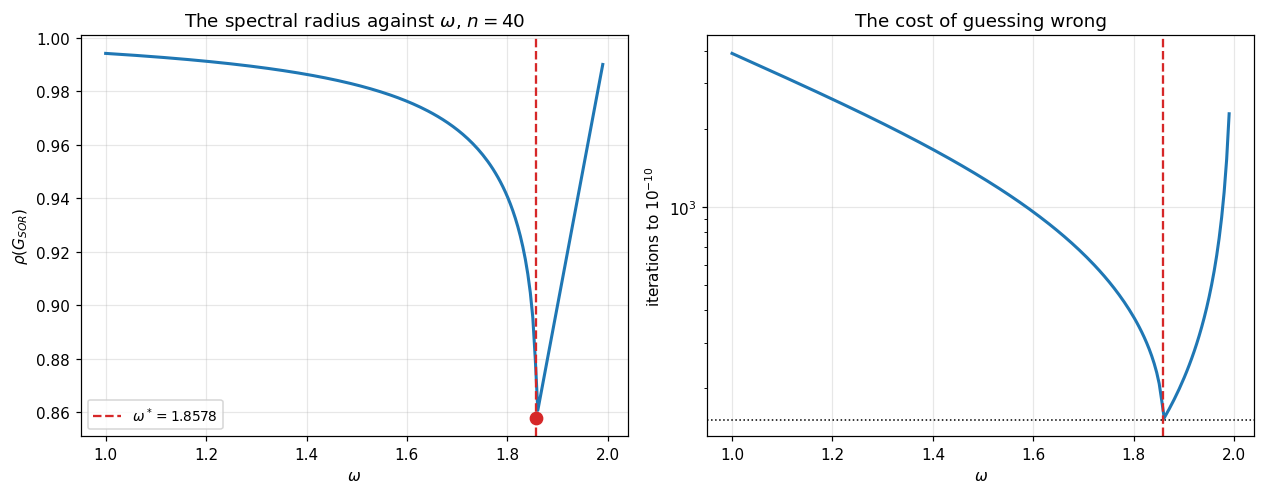

optimal omega = 1.857788, needing 150 iterations

     omega          rho    iterations   times optimal
------------------------------------------------------
    1.0000     0.994140          3918           26.10
    1.7578     0.954556           495            3.30
    1.8378     0.915037           259            1.73
    1.8578     0.857788           150            1.00
    1.8778     0.877788           177            1.18
    1.9578     0.957788           534            3.56
    1.9900     0.990000          2291           15.26

the curve is STEEP to the left of the optimum and gentle to the right.
guessing 0.10 too low costs about twice the work; guessing 0.10 too high
costs much less. so when omega must be guessed, guess HIGH.

that asymmetry is why adaptive SOR schemes creep upward rather than
bracketing the optimum from both sides.


In [12]:
size = 40
M = bd.second_difference(size)
om_star = it.optimal_omega(M)
omegas = np.linspace(1.0, 1.99, 200)
rhos = np.array([it.spectral_radius(it.iteration_matrix(M, "sor", w)) for w in omegas])
counts = np.array([it.iterations_needed(r) for r in rhos])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.6, 4.6))
axL.plot(omegas, rhos, "C0-", lw=2)
axL.axvline(om_star, color="C3", ls="--", lw=1.5, label=fr"$\omega^* = {om_star:.4f}$")
axL.plot(om_star, om_star - 1, "C3o", ms=8)
axL.set_xlabel(r"$\omega$"); axL.set_ylabel(r"$\rho(G_{SOR})$")
axL.set_title(f"The spectral radius against $\\omega$, $n = {size}$")
axL.legend(fontsize=9)

axR.semilogy(omegas, counts, "C0-", lw=2)
axR.axvline(om_star, color="C3", ls="--", lw=1.5)
axR.axhline(it.iterations_needed(om_star - 1), color="k", ls=":", lw=1)
axR.set_xlabel(r"$\omega$"); axR.set_ylabel("iterations to $10^{-10}$")
axR.set_title("The cost of guessing wrong")
plt.tight_layout()
plt.show()

print(f"optimal omega = {om_star:.6f}, needing {it.iterations_needed(om_star-1):.0f} iterations\n")
print(f"{'omega':>10} {'rho':>12} {'iterations':>13} {'times optimal':>15}")
print("-" * 54)
best = it.iterations_needed(om_star - 1)
for w in [1.0, om_star - 0.10, om_star - 0.02, om_star, om_star + 0.02,
          min(om_star + 0.10, 1.99), 1.99]:
    r = it.spectral_radius(it.iteration_matrix(M, "sor", w))
    k = it.iterations_needed(r)
    print(f"{w:>10.4f} {r:>12.6f} {k:>13.0f} {k/best:>15.2f}")

print()
print("the curve is STEEP to the left of the optimum and gentle to the right.")
print("guessing 0.10 too low costs about twice the work; guessing 0.10 too high")
print("costs much less. so when omega must be guessed, guess HIGH.")
print()
print("that asymmetry is why adaptive SOR schemes creep upward rather than")
print("bracketing the optimum from both sides.")

## 6. What all three have in common

Every method here converges slowly for the same reason, and seeing it is what motivates the
rest of Part 4.

For the second difference matrix the Jacobi iteration matrix is $G_J = I - \tfrac12 A$, whose
eigenvectors are the grid sine modes $\sin(k\pi x)$ with eigenvalues

$$\lambda_k = \cos(k\pi h), \qquad h = \frac{1}{n+1}.$$

Each mode of the error is multiplied by its own $\lambda_k$ every sweep, independently of all
the others. So the question "how fast does Jacobi converge" is really $n$ separate questions.

In [13]:
size = 63
h = 1.0 / (size + 1)
modes = np.arange(1, size + 1)
lam_plain = np.abs(np.cos(modes * np.pi * h))

print("how much one Jacobi sweep shrinks each frequency\n")
print(f"{'mode k':>8} {'k/n':>7} {'|lambda_k|':>13} {'behaviour':>22}")
print("-" * 54)
for k in [1, 8, 16, 31, 32, 48, 56, 63]:
    lam = abs(np.cos(k * np.pi * h))
    if lam > 0.9:
        note = "barely damped"
    elif lam > 0.5:
        note = "slowly damped"
    else:
        note = "killed quickly"
    print(f"{k:>8} {k/size:>7.2f} {lam:>13.6f} {note:>22}")

print()
print("read the ends and the middle separately, because they behave differently.")
print()
print("the MIDDLE modes vanish almost instantly: cos(pi/2) = 0.")
print("the LOWEST mode is barely touched, |lambda| = 0.9988.")
print("the HIGHEST mode is ALSO barely touched, |lambda| = 0.9988.")
print()
print("that last line is the surprise. plain Jacobi is bad at BOTH ends of the")
print("spectrum, not just the smooth end, because cos(k pi h) approaches -1 as")
print("k approaches n. the eigenvalue is near -1, so the mode flips sign each")
print("sweep and hardly shrinks.")

how much one Jacobi sweep shrinks each frequency

  mode k     k/n    |lambda_k|              behaviour
------------------------------------------------------
       1    0.02      0.998795          barely damped
       8    0.13      0.923880          barely damped
      16    0.25      0.707107          slowly damped
      31    0.49      0.049068         killed quickly
      32    0.51      0.000000         killed quickly
      48    0.76      0.707107          slowly damped
      56    0.89      0.923880          barely damped
      63    1.00      0.998795          barely damped

read the ends and the middle separately, because they behave differently.

the MIDDLE modes vanish almost instantly: cos(pi/2) = 0.
the LOWEST mode is barely touched, |lambda| = 0.9988.
the HIGHEST mode is ALSO barely touched, |lambda| = 0.9988.

that last line is the surprise. plain Jacobi is bad at BOTH ends of the
spectrum, not just the smooth end, because cos(k pi h) approaches -1 as
k approaches n. t

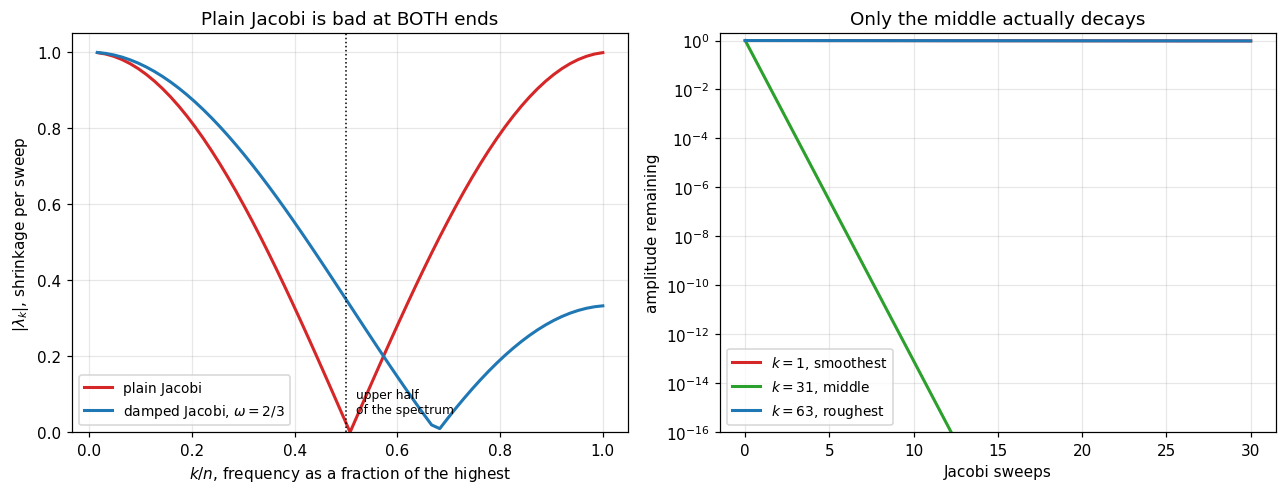

worst shrinkage over the UPPER half of the spectrum:
   plain Jacobi      : 0.998795   <- useless as a smoother
   damped, omega=2/3 : 0.333333   <- a good smoother

damping trades the middle for the top. it is WORSE on the modes plain
Jacobi already handled and far better on the rough ones, and it is
exactly the rough ones a coarse grid cannot represent.

that is why lesson 28 uses DAMPED Jacobi and not plain Jacobi. the
choice omega = 2/3 minimises the worst case over the upper half, and
1/3 is the best any weighting can achieve there.


In [14]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.8, 4.6))

omega_damped = 2.0 / 3.0
lam_damped = np.abs(1.0 - omega_damped * (1.0 - np.cos(modes * np.pi * h)))

axL.plot(modes / size, lam_plain, "C3-", lw=2, label="plain Jacobi")
axL.plot(modes / size, lam_damped, "C0-", lw=2,
         label=fr"damped Jacobi, $\omega = 2/3$")
axL.axvline(0.5, color="k", ls=":", lw=1)
axL.text(0.52, 0.05, "upper half\nof the spectrum", fontsize=8)
axL.set_xlabel("$k/n$, frequency as a fraction of the highest")
axL.set_ylabel(r"$|\lambda_k|$, shrinkage per sweep")
axL.set_ylim(0, 1.05)
axL.set_title("Plain Jacobi is bad at BOTH ends")
axL.legend(fontsize=9, loc="lower left")

grid = np.arange(1, size + 1) * h
for k, colour, label in [(1, "C3", "$k = 1$, smoothest"),
                         (size // 2, "C2", f"$k = {size//2}$, middle"),
                         (size, "C0", f"$k = {size}$, roughest")]:
    lam = np.cos(k * np.pi * h)
    axR.semilogy(np.abs(lam) ** np.arange(31), color=colour, lw=2, label=label)
axR.set_xlabel("Jacobi sweeps")
axR.set_ylabel("amplitude remaining")
axR.set_ylim(1e-16, 2)
axR.set_title("Only the middle actually decays")
axR.legend(fontsize=9)

plt.tight_layout()
plt.show()

upper = modes > size / 2
print(f"worst shrinkage over the UPPER half of the spectrum:")
print(f"   plain Jacobi      : {lam_plain[upper].max():.6f}   <- useless as a smoother")
print(f"   damped, omega=2/3 : {lam_damped[upper].max():.6f}   <- a good smoother")
print()
print("damping trades the middle for the top. it is WORSE on the modes plain")
print("Jacobi already handled and far better on the rough ones, and it is")
print("exactly the rough ones a coarse grid cannot represent.")
print()
print("that is why lesson 28 uses DAMPED Jacobi and not plain Jacobi. the")
print("choice omega = 2/3 minimises the worst case over the upper half, and")
print("1/3 is the best any weighting can achieve there.")
assert lam_plain[upper].max() > 0.9
assert lam_damped[upper].max() < 0.4

**What to take from this.** The error is not one thing decaying at one rate. It is $n$ modes
decaying at $n$ different rates, and the slowest of them sets $\rho(G)$.

The **smooth** modes are the permanent difficulty: no local update can move them quickly,
because a smooth error looks locally like a constant, and a constant is nearly invisible to a
stencil that only compares neighbours.

Two very different fixes follow, and Part 4 spends the rest of its lessons on them:

- **Lesson 24** stops taking steps of a size fixed in advance, and chooses each step optimally
  instead. That is conjugate gradient, and it turns $O(\kappa)$ iterations into
  $O(\sqrt{\kappa})$.
- **Lesson 28** keeps a smoother, damped Jacobi being the standard choice, and sends the smooth
  part of the error to a **coarser grid** where it is no longer smooth. That is multigrid, and
  it removes the dependence on $n$ altogether.

## 7. Complexity

| Quantity | Cost |
|---|---|
| One Jacobi sweep | $2\,\text{nnz}$, one matvec |
| One Gauss-Seidel sweep | $2\,\text{nnz}$, a forward solve |
| One SOR sweep | $2\,\text{nnz}$ plus $n$ |
| Memory | $A$ plus one or two vectors |
| Iterations, Jacobi or GS, model problem | $O(n^2)$ in 1D, so $O(n^3)$ total |
| Iterations, optimal SOR | $O(n)$ in 1D, so $O(n^2)$ total |
| Forming $G$ explicitly | $O(n^3)$ and dense. **Never do this outside a lesson** |

## 8. Common mistakes

1. **Forming the iteration matrix in a real solve.** It is dense even when $A$ is sparse.
   `nalib.iterative.iteration_matrix` exists to measure $\rho$, not to iterate with.
2. **Using $\|G\| < 1$ as the criterion.** It is sufficient, not necessary. $\rho(G) < 1$ is
   the condition.
3. **Expecting the asymptotic rate immediately.** The transient is governed by the norm
   (lesson 15 section 6).
4. **Taking $\omega$ outside $(0,2)$.** Kahan's theorem forbids it, and `sor` refuses.
5. **Guessing $\omega$ too low.** Section 5 measured the curve is much steeper on the low side.
6. **Expecting Gauss-Seidel to be a different order from Jacobi.** It is exactly a factor of
   two, at every size.
7. **Using these as solvers rather than smoothers on large problems.** Section 6: the smooth
   part of the error barely moves.

## 9. Exercises

**Level 1, conceptual**

1.1 Why can Jacobi be parallelised and Gauss-Seidel not?

1.2 An iteration has $\rho(G) = 0.999$. How many sweeps to gain ten digits?

1.3 Why does the iteration count for Jacobi grow like $n^2$ on the model problem?

**Level 2, mathematical**

2.1 Prove Theorem 23.1 in both directions, being careful about the "for every starting vector"
part.

2.2 Prove that strict diagonal dominance implies $\|G_{\text{J}}\|_\infty < 1$, hence Jacobi
converges.

2.3 Prove Kahan's theorem, that $\rho(G_{\text{SOR}}) \ge |\omega - 1|$.

2.4 Prove that Gauss-Seidel converges for every symmetric positive definite $A$, using the
energy $\mathbf{e}^TA\mathbf{e}$ as a decreasing quantity.

2.5 Derive $\rho_J = \cos(\pi h)$ for the second difference matrix from the eigenvalues in
lesson 21, and hence the $O(h^2)$ and $O(h)$ statements.

**Level 3, computational**

3.1 Implement Jacobi and Gauss-Seidel for a **matrix-free** operator, given only a function
computing $A\mathbf{x}$ and the diagonal. Test on the second difference operator with no matrix
stored.

3.2 Implement **red-black Gauss-Seidel**, which colours the grid so that all red points can be
updated in parallel, then all black. Confirm it has the same convergence rate as ordinary
Gauss-Seidel while being parallelisable.

3.3 Implement **adaptive SOR**, estimating $\rho_J$ from the observed convergence and updating
$\omega$ as it goes. Compare against the optimal $\omega$ and against a fixed guess.

**Level 4, experimental**

4.1 Measure how the ordering of unknowns changes Gauss-Seidel's rate. Try natural, reversed,
red-black and random orderings on the same matrix.

4.2 Measure the transient: for a matrix with $\rho(G) < 1$ but $\|G\|_2 > 1$, plot the residual
against sweeps and find how many sweeps pass before the asymptotic rate takes over.

4.3 Reproduce section 6's frequency experiment for Gauss-Seidel and SOR. Does SOR smooth as
well as Jacobi does? This decides whether SOR is a good multigrid smoother.

**Level 5, advanced**

5.1 **Consistent ordering and property A.** State both precisely, prove Theorem 23.4 for
matrices with these properties, and find a matrix where Gauss-Seidel is **slower** than Jacobi,
showing the theorem's hypotheses are needed.

5.2 **Chebyshev acceleration.** A stationary iteration can be accelerated by taking a weighted
combination of previous iterates with Chebyshev polynomial coefficients, improving the rate
from $\rho$ to about $\rho/(1+\sqrt{1-\rho^2})$. Derive it, implement it, and compare against
SOR. Note that it needs eigenvalue bounds, which conjugate gradient does not.

5.3 **Why these are the wrong methods.** Each of Jacobi, Gauss-Seidel and SOR takes a step of a
size fixed in advance. Argue that choosing the step **optimally** at each iteration must do at
least as well, derive steepest descent from that principle, and explain why steepest descent is
still not good enough. Lesson 24 supplies the answer.

## 10. Key takeaways

- **An iterative method never factorizes**, so it needs only the memory $A$ already occupies
  and only the ability to compute $A\mathbf{x}$. Measured: at $n = 10^5$ you could afford eight
  hundred million sweeps for the price of one dense factorization.
- **Every stationary method is a splitting** $A = M - N$ giving $G = M^{-1}N$. Jacobi takes
  $M = D$, Gauss-Seidel $M = D+L$, SOR $M = D/\omega + L$.
- **Convergence is exactly $\rho(G) < 1$**, and the rate is $\rho(G)$. This is lesson 10's
  scalar theorem for the third time, now with a spectral radius. A norm bound is sufficient and
  not necessary.
- **Gauss-Seidel is exactly twice as fast as Jacobi** on the model problem, because
  $\rho_{\text{GS}} = \rho_{\text{J}}^2$. Verified to eight decimal places at every size. It is
  a constant factor, and it costs parallelism and introduces an ordering dependence.
- **Both scale as $O(n^2)$ iterations** because $\rho_J = \cos(\pi h) = 1 - O(h^2)$. With
  $O(n)$ work per sweep the total is $O(n^3)$, **the same order as the dense factorization
  these methods exist to avoid**.
- **SOR changes the order**, not the constant: $\rho(\omega^\ast) = \omega^\ast - 1 = 1 - O(h)$,
  taking the count to $O(n)$. Measured: at $n = 320$ SOR needs about seventy times fewer
  iterations than Gauss-Seidel, and the advantage grows with $n$.
- **Kahan's theorem** confines $\omega$ to $(0,2)$, and $\rho(G_{\text{SOR}}(\omega^\ast)) =
  \omega^\ast - 1$ exactly, verified at every size.
- **The optimum is asymmetric.** Measured: guessing $\omega$ too low costs far more than
  guessing too high, so when in doubt guess high.
- **The error is $n$ modes decaying at $n$ different rates**, with eigenvalues
  $\lambda_k = \cos(k\pi h)$ for Jacobi on the model problem. The slowest sets $
ho(G)$.
- **Plain Jacobi is bad at BOTH ends of the spectrum**, not only the smooth end. Measured: the
  worst shrinkage over the upper half of the spectrum is **0.9988**, because $\cos(k\pi h)$
  approaches $-1$ as $k$ approaches $n$. Only the middle modes decay quickly. That makes plain
  Jacobi a poor smoother, which is a genuine surprise.
- **Damped Jacobi with $\omega = 2/3$ fixes it**, bringing the worst upper-half shrinkage to
  **0.3333**. It trades the middle for the top, and the top is exactly what a coarse grid cannot
  represent. **This is why lesson 28 uses damped Jacobi and not plain Jacobi.**

## Where this goes next

Two different escapes from the same problem.

**Lesson 24** stops taking steps of a size fixed in advance and chooses each step optimally
instead. Conjugate gradient turns $O(\kappa)$ iterations into $O(\sqrt{\kappa})$ and needs no
parameter like $\omega$ at all. **Lesson 25** then reduces $\kappa$ itself, and lesson 25 also
recycles the splittings of this lesson as preconditioners, so the work here is not discarded.

**Lesson 28** keeps the smoother and fixes what it cannot do: transfer the smooth part of the
error to a coarser grid, where it is no longer smooth, and solve it there. That gives
mesh-independent convergence, the only method in the course whose iteration count does not grow
with $n$ at all.

Solutions are in [`solutions/part04_iterative_and_krylov.md`](../solutions/part04_iterative_and_krylov.md).